# Activation Functions

In Lesson 02, we built the original Perceptron and discovered its fatal mathematical flaw: the Step Function. Because a Step Function is a rigid, flat line that instantly jumps from 0 to 1, its derivative (slope) is exactly zero almost everywhere. If the derivative is zero, the gradient is zero, and Calculus-based learning algorithms freeze.

To build Deep Neural Networks that can actually learn, we must replace the rigid Step Function with continuous, differentiable curves. These are called **Activation Functions**.

Furthermore, without Activation Functions, Neural Networks are completely useless. If you stack 100 linear layers together without an activation function in between them, the mathematics collapse. A linear function of a linear function is just a single linear function. Activation functions introduce **Non-Linearity**, allowing the network to wrap its decision boundaries around incredibly complex, curved data.

Let's set up our PyTorch environment to explore the mathematics of non-linearity.

In [1]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import seaborn as sns

# Set professional visualization styling
sns.set_theme(style="whitegrid")

print("✅ PyTorch Activation Functions Environment Ready.")

✅ PyTorch Activation Functions Environment Ready.


# 1. The S-Curves (Sigmoid and Tanh)

In the early days of Deep Learning, researchers wanted functions that mimicked biological neurons (firing or not firing) but possessed smooth, calculable derivatives.

### Sigmoid

The Sigmoid function takes any real-valued number and mathematically "squashes" it into a strict range between 0 and 1.


$$f(x) = \frac{1}{1 + e^{-x}}$$

* **Pros**: Excellent for outputting probabilities (e.g., "There is an 85% chance this is fraud").
* **Cons (The Vanishing Gradient)**: Look at the extremes of the function. If $x = 100$, the output is 0.9999. The curve becomes completely flat. If the curve is flat, the derivative is near zero, and the network stops learning. Because of this, Sigmoid is almost never used in the hidden layers of modern networks.

### Tanh (Hyperbolic Tangent)

Tanh is a scaled version of Sigmoid that squashes numbers between -1 and 1.


$$f(x) = \frac{e^x - e^{-x}}{e^x + e^{-x}}$$

* **Pros**: It is zero-centered. This makes gradient descent optimization much faster and more stable compared to Sigmoid.
* **Cons**: It still suffers from the Vanishing Gradient problem at extreme positive or negative values.

# 2. The Rectifiers (ReLU and Variants)

To solve the Vanishing Gradient problem, modern Deep Learning shifted to a shockingly simple mathematical function in 2012. It triggered the current AI revolution.

### ReLU (Rectified Linear Unit)

ReLU outputs the input directly if it is positive; otherwise, it outputs zero.


$$f(x) = \max(0, x)$$

* **Pros**: For any positive number, the derivative (slope) is exactly 1. The gradient never vanishes! It is also computationally incredibly cheap.
* **Cons (The Dying ReLU Problem)**: For any negative number, the output is exactly zero, and the derivative is exactly zero. If a large negative bias pushes a neuron into the negative zone, that neuron "dies" and may never recover during training.

### Leaky ReLU

To fix the Dying ReLU problem, Leaky ReLU allows a tiny, non-zero gradient when the input is negative.


$$f(x) = \max(0.01x, x)$$

### GELU (Gaussian Error Linear Unit)

The state-of-the-art standard. Instead of a hard, sharp angle at zero like ReLU, GELU uses a smooth, curved transition mathematically derived from the Gaussian distribution. **This is the default activation function used inside modern Transformers like ChatGPT.**

# 3. Implementing and Visualizing Activations in Code

Let's generate a tensor containing a sequence of numbers from -5 to 5, pass them through PyTorch's native activation functions, and plot the resulting mathematical curves.

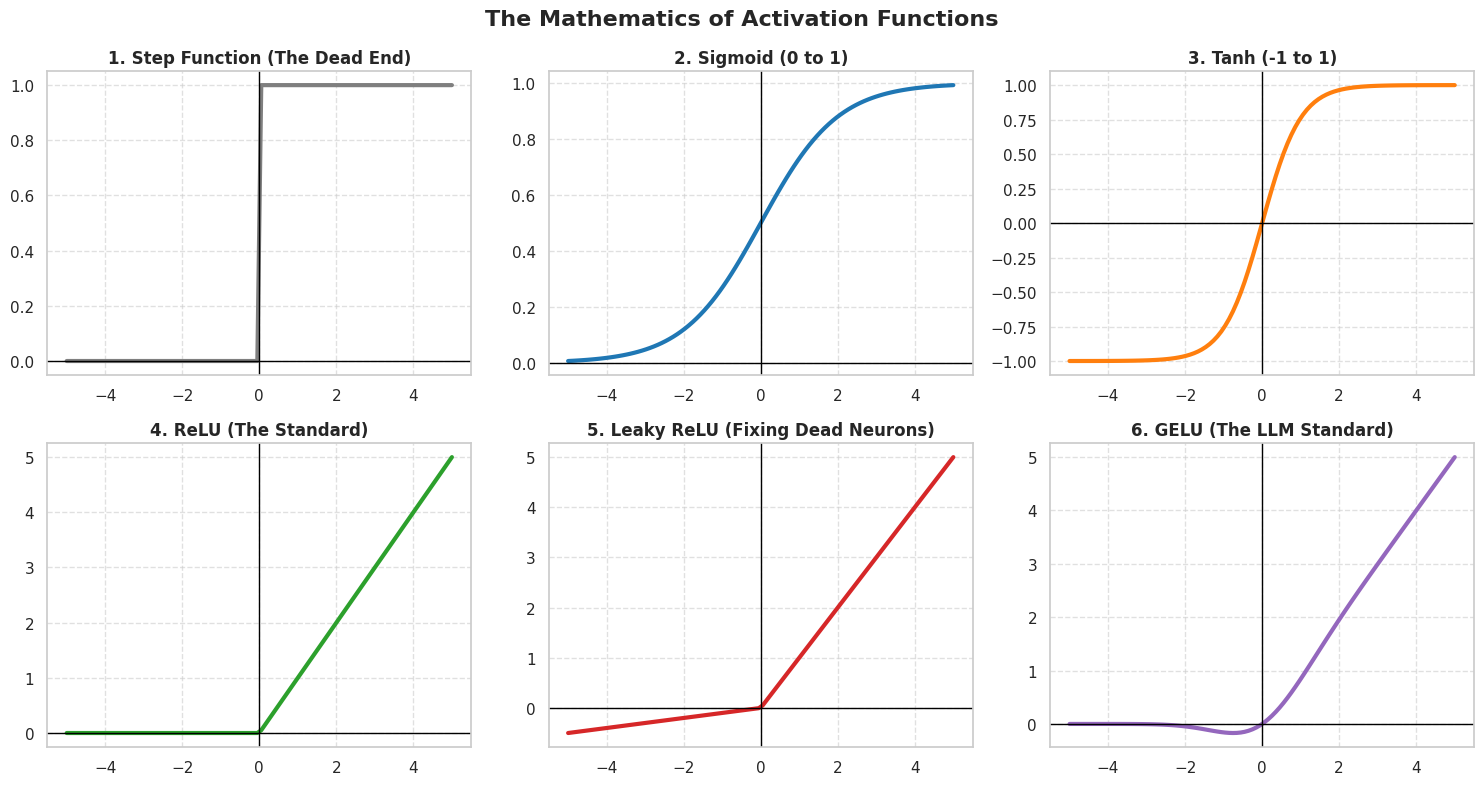

In [2]:
# 1. Create a 1D Tensor from -5 to 5 with 100 steps
x = torch.linspace(-5, 5, 100)

# 2. Apply Activation Functions
y_step = torch.where(x > 0, torch.tensor(1.0), torch.tensor(0.0)) # The old Perceptron
y_sigmoid = torch.sigmoid(x)
y_tanh = torch.tanh(x)
y_relu = F.relu(x)
y_leaky_relu = F.leaky_relu(x, negative_slope=0.1) # Exaggerated slope for visual clarity
y_gelu = F.gelu(x)

# 3. Matplotlib Visualization
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle("The Mathematics of Activation Functions", fontsize=16, fontweight='bold')

# Plotting each function
def plot_activation(ax, x_data, y_data, title, color):
    ax.plot(x_data.numpy(), y_data.numpy(), color=color, linewidth=3)
    ax.axhline(0, color='black', linewidth=1)
    ax.axvline(0, color='black', linewidth=1)
    ax.set_title(title, fontweight='bold')
    ax.grid(True, linestyle='--', alpha=0.6)

plot_activation(axes[0,0], x, y_step, "1. Step Function (The Dead End)", '#7f7f7f')
plot_activation(axes[0,1], x, y_sigmoid, "2. Sigmoid (0 to 1)", '#1f77b4')
plot_activation(axes[0,2], x, y_tanh, "3. Tanh (-1 to 1)", '#ff7f0e')
plot_activation(axes[1,0], x, y_relu, "4. ReLU (The Standard)", '#2ca02c')
plot_activation(axes[1,1], x, y_leaky_relu, "5. Leaky ReLU (Fixing Dead Neurons)", '#d62728')
plot_activation(axes[1,2], x, y_gelu, "6. GELU (The LLM Standard)", '#9467bd')

plt.tight_layout()
plt.show()

*(Insight: Look closely at the bottom row. Notice how ReLU has a sharp, jagged corner at $x=0$. That sharp corner is mathematically non-differentiable. Now look at GELU. It slightly dips below zero and curves smoothly upward. That microscopic mathematical smoothness allows massive 100-billion parameter networks to optimize flawlessly.)*

## Real-World Use Case or Analogy:

Think of an Activation Function like a **Water Valve in a Dam**:

* **Step Function**: A heavy steel door that is either 100% closed or 100% open. You cannot adjust the flow.
* **Linear Function (No Activation)**: A pipe with no valve at all. Whatever water comes in goes straight out. If you connect 100 pipes together, it just acts like one giant, boring pipe.
* **Sigmoid**: A carefully calibrated twist-valve. No matter how much pressure builds up behind it (massive input), it only lets out a perfectly steady, constrained trickle of water between 0 and 1 gallons per minute.
* **ReLU**: A one-way backflow preventer. If water tries to flow backward (negative), it aggressively slams shut and stops the flow (0). If water flows forward (positive), it swings completely open and lets the exact amount of water pass through unhindered.